# School Data Analysis with Pandas, Seaborn & Matplotlib

### What this notebook covers

- Loading and exploring a real-structured school dataset from CSV
- Identifying and handling missing values
- Descriptive statistics by year group, gender, and house
- Visualisations: distribution plots, pie charts, line charts, heatmaps
- Correlation analysis across academic and pastoral data
- Feature engineering: academic progress, pastoral risk flags
- Pivot tables for cross-tabulated insight
- Predictive indicators: linking pastoral patterns to academic performance

---

### Dataset columns

| Column | Description |
|---|---|
| `pupil_id` | Unique pupil identifier |
| `year_group` | School year (7–11) |
| `gender` | Male / Female |
| `house` | Tutor house |
| `pupil_premium` | 1 = eligible for pupil premium funding |
| `send_register` | 1 = on SEND register |
| `attendance_pct` | Attendance percentage |
| `maths/english/science_grade_y1/y2` | GCSE-style grade (1–9) across two report cycles |
| `effort_maths/english/science` | Effort score (1–5) |
| `predicted_grade` | Teacher-predicted overall grade |
| `rewards` | Total reward points this year |
| `sanctions` | Total sanction points this year |
| `cpoms_count` | Number of concern logs on CPOMS |
| `behaviour_flag` | 1 = flagged for pastoral review |


## 1. Import libraries and configure display

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set consistent plot style throughout the notebook
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")
pd.set_option('display.max_columns', 30)  # show all columns in outputs

print("Libraries loaded successfully")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}")


Libraries loaded successfully
pandas 2.3.3  |  numpy 2.3.5  |  seaborn 0.13.2


## 2. Load the school dataset from CSV

In [2]:
# Load dataset from CSV — no numpy generation needed
df = pd.read_csv('school_data.csv')

# Quick peek at the first few rows
print(f"Dataset shape: {df.shape[0]} pupils, {df.shape[1]} columns")
df.head()


Dataset shape: 200 pupils, 21 columns


,pupil_id,year_group,gender,house,pupil_premium,send_register,attendance_pct,maths_grade_y1,english_grade_y1,science_grade_y1,maths_grade_y2,english_grade_y2,science_grade_y2,effort_maths,effort_english,effort_science,predicted_grade,rewards,sanctions,cpoms_count,behaviour_flag
0,P0001,8,Female,Atkinson,0,0,97.200000,4,4,6,3.0,5.0,6.0,3.0,3.0,3.0,5.0,13.0,5,1.0,0
1,P0002,11,Female,Darwin,1,0,NaN,6,8,4,6.0,9.0,3.0,3.0,3.0,2.0,7.0,8.0,0,2.0,0
2,P0003,10,Male,Darwin,0,0,93.500000,9,9,5,9.0,9.0,6.0,3.0,4.0,NaN,8.0,7.0,3,2.0,0
3,P0004,9,Male,Brunel,1,0,96.812988,8,5,9,9.0,4.0,9.0,3.0,2.0,3.0,7.0,8.0,2,1.0,0
4,P0005,7,Female,Churchill,0,0,95.500000,8,5,9,NaN,4.0,9.0,3.0,NaN,2.0,6.0,9.0,5,1.0,0


In [44]:
# Check column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pupil_id          200 non-null    object 
 1   year_group        200 non-null    int64  
 2   gender            200 non-null    object 
 3   house             200 non-null    object 
 4   pupil_premium     200 non-null    int64  
 5   send_register     200 non-null    int64  
 6   attendance_pct    190 non-null    float64
 7   maths_grade_y1    200 non-null    int64  
 8   english_grade_y1  200 non-null    int64  
 9   science_grade_y1  200 non-null    int64  
 10  maths_grade_y2    192 non-null    float64
 11  english_grade_y2  192 non-null    float64
 12  science_grade_y2  192 non-null    float64
 13  effort_maths      188 non-null    float64
 14  effort_english    188 non-null    float64
 15  effort_science    188 non-null    float64
 16  predicted_grade   186 non-null    float64
 1

In [47]:
# High-level summary statistics for all numeric columns
df.describe().round(2)

,year_group,pupil_premium,send_register,attendance_pct,maths_grade_y1,english_grade_y1,science_grade_y1,maths_grade_y2,english_grade_y2,science_grade_y2,effort_maths,effort_english,effort_science,predicted_grade,rewards,sanctions,cpoms_count,behaviour_flag
count,200.00,200.00,200.00,190.00,200.00,200.00,200.00,192.00,192.00,192.00,188.00,188.00,188.00,186.00,190.00,200.00,192.00,200.00
mean,8.92,0.30,0.12,92.37,5.49,5.56,5.54,5.67,5.75,5.84,3.18,3.15,2.94,5.78,7.74,3.12,1.97,0.01
std,1.47,0.46,0.33,5.19,1.75,1.63,1.81,1.87,1.93,1.95,0.96,0.94,1.01,1.28,2.61,1.70,1.39,0.10
min,7.00,0.00,0.00,73.86,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,1.00,0.00,0.00,0.00
25%,8.00,0.00,0.00,88.39,4.00,4.00,4.00,4.00,4.00,4.75,3.00,3.00,2.00,5.00,6.00,2.00,1.00,0.00
50%,9.00,0.00,0.00,92.90,5.00,6.00,6.00,6.00,6.00,6.00,3.00,3.00,3.00,6.00,7.00,3.00,2.00,0.00
75%,10.00,1.00,0.00,96.60,7.00,7.00,7.00,7.00,7.00,7.00,4.00,4.00,4.00,7.00,9.00,4.00,3.00,0.00
max,11.00,1.00,1.00,100.00,9.00,9.00,9.00,9.00,9.00,9.00,5.00,5.00,5.00,9.00,14.00,8.00,8.00,1.00


## 3. Missing value analysis
In schools, missing grade entries typically mean a teacher did not submit a report on time.

In [3]:
# Count and percentage of missing values per column
# Realistic causes in school data:
#   attendance_pct   — pupil joined mid-year; full-year figure unavailable
#   *_grade_y2       — teacher did not submit Y2 report in time
#   effort_*         — not all teachers completed effort ratings this cycle
#   predicted_grade  — some teachers yet to submit their predictions
#   rewards          — gaps in the rewards data entry system
#   cpoms_count      — some pastoral records not yet linked to pupil IDs
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
attendance_pct,10,5.0
maths_grade_y2,8,4.0
english_grade_y2,8,4.0
science_grade_y2,8,4.0
effort_maths,12,6.0
effort_english,12,6.0
effort_science,12,6.0
predicted_grade,14,7.0
rewards,10,5.0
cpoms_count,8,4.0


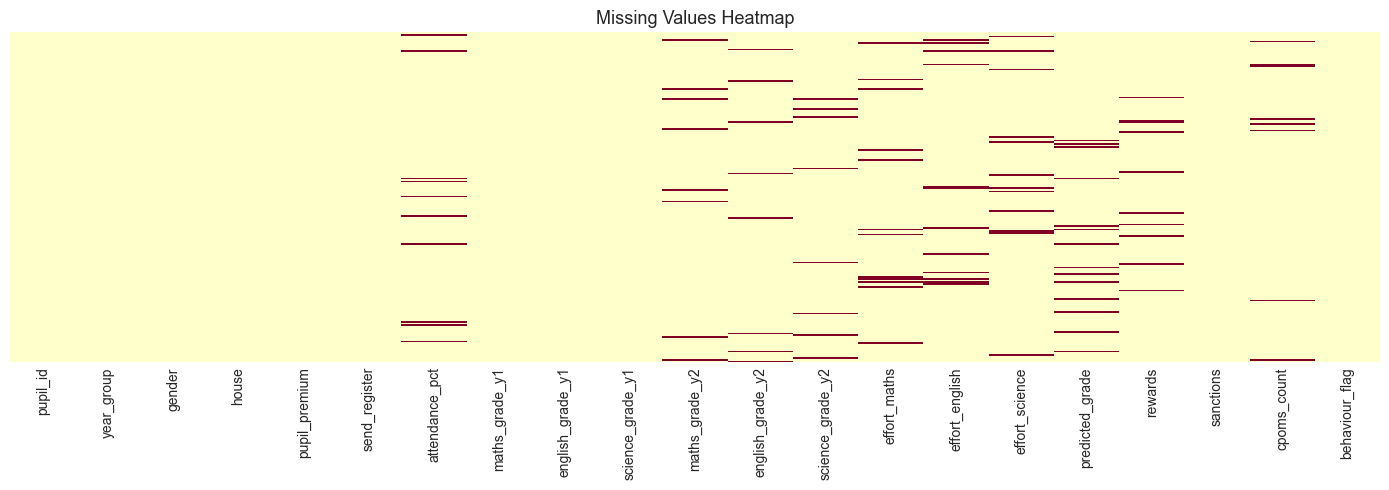

In [4]:
# Visualise missing data as a heatmap
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='YlOrRd', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# --- Strategy 1: Median imputation for Y2 grades and attendance ---
# Median is robust to outliers; suitable for skewed grade distributions

for col in ['maths_grade_y2', 'english_grade_y2', 'science_grade_y2', 'attendance_pct']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: imputed {df[col].isna().sum()} remaining NaNs with median={median_val:.2f}")

# --- Strategy 2: Mode imputation for effort scores (discrete 1–5 scale) ---
# Mode preserves the most common rating rather than a fractional median
for col in ['effort_maths', 'effort_english', 'effort_science']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: imputed with mode={mode_val}")

# --- Strategy 3: Median imputation for predicted grade ---
for col in ['predicted_grade']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: imputed with median={median_val:.2f}")

# --- Strategy 4: Zero-fill for rewards and cpoms_count ---
# A missing entry in the rewards/CPOMS system most likely means no record exists,
# which is functionally equivalent to a count of zero
for col in ['rewards', 'cpoms_count']:
    df[col] = df[col].fillna(0)
    print(f"  {col}: missing entries filled with 0 (no record = no count)")

print("\nMissing values after imputation:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "  None — all columns fully imputed")

  maths_grade_y2: imputed 0 remaining NaNs with median=6.00
  english_grade_y2: imputed 0 remaining NaNs with median=6.00
  science_grade_y2: imputed 0 remaining NaNs with median=6.00
  attendance_pct: imputed 0 remaining NaNs with median=92.90
  effort_maths: imputed with mode=3.0
  effort_english: imputed with mode=3.0
  effort_science: imputed with mode=3.0
  predicted_grade: imputed with median=6.00
  rewards: missing entries filled with 0 (no record = no count)
  cpoms_count: missing entries filled with 0 (no record = no count)

Missing values after imputation:
  None — all columns fully imputed


#### How can you check there is no more missing data?

## 4. Distribution of grades
GCSE grades run from 1 (lowest) to 9 (highest). Understanding the spread tells us where most pupils sit.

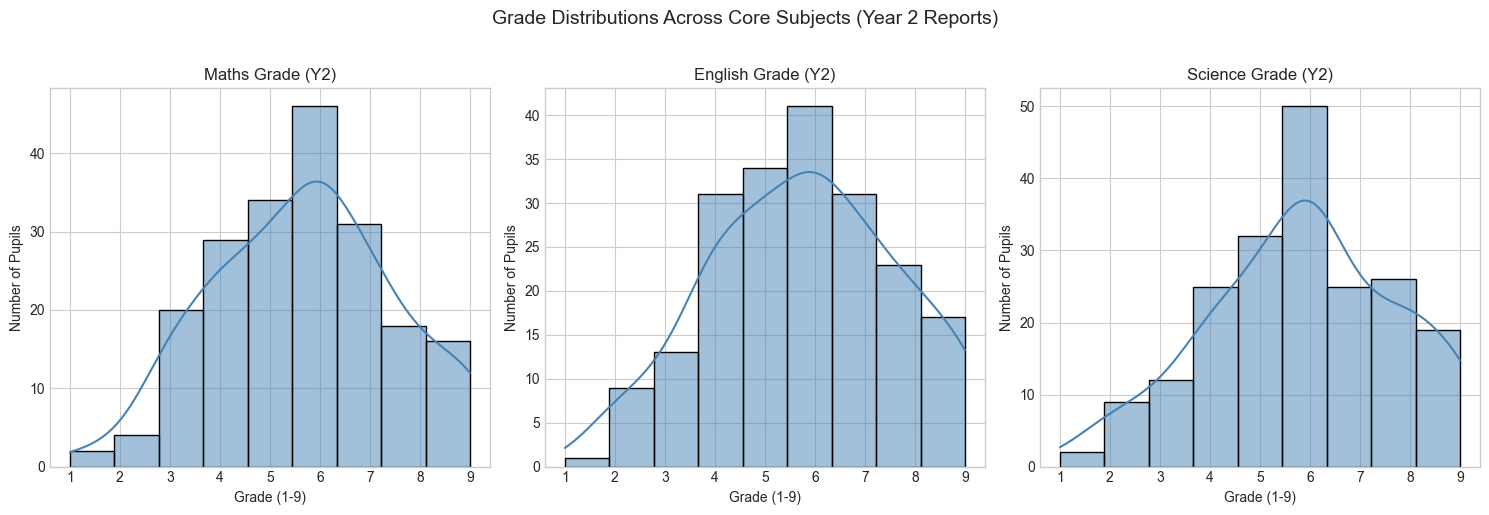

In [6]:
# Distribution plots for Y2 grades across three subjects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
subjects = ['maths_grade_y2', 'english_grade_y2', 'science_grade_y2']
titles   = ['Maths Grade (Y2)', 'English Grade (Y2)', 'Science Grade (Y2)']

for ax, col, title in zip(axes, subjects, titles):
    sns.histplot(df[col], bins=9, kde=True, ax=ax, color='steelblue')  # kde=True adds density curve
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Grade (1-9)')
    ax.set_ylabel('Number of Pupils')

plt.suptitle('Grade Distributions Across Core Subjects (Year 2 Reports)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**How to interpret a box plot**

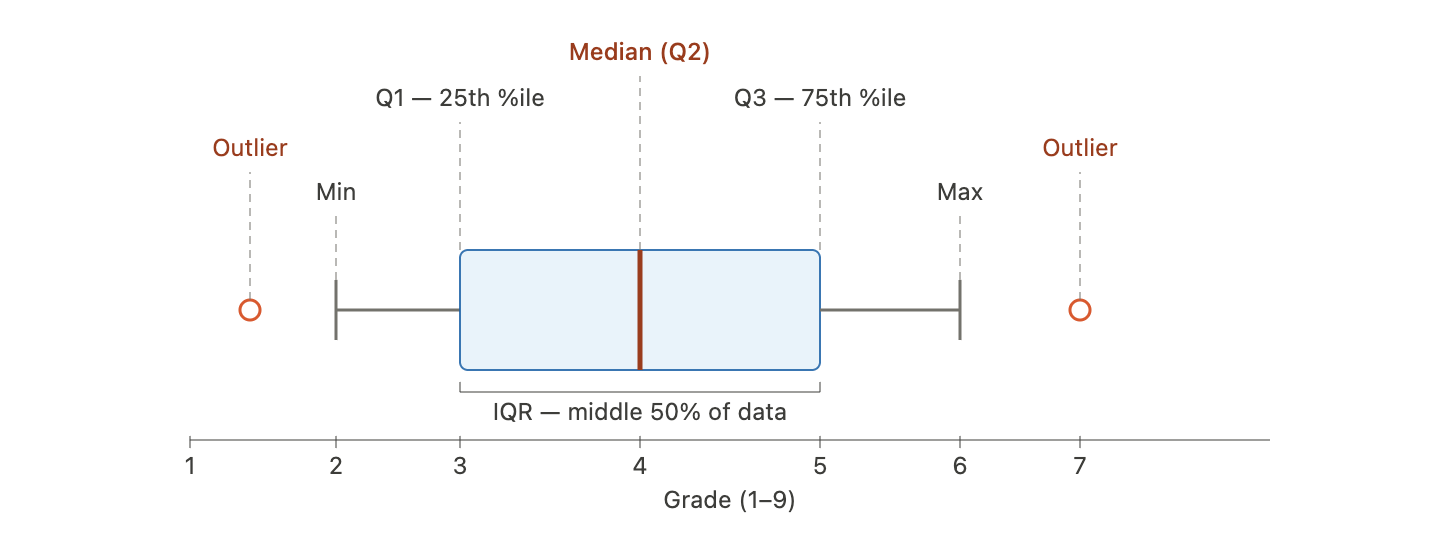

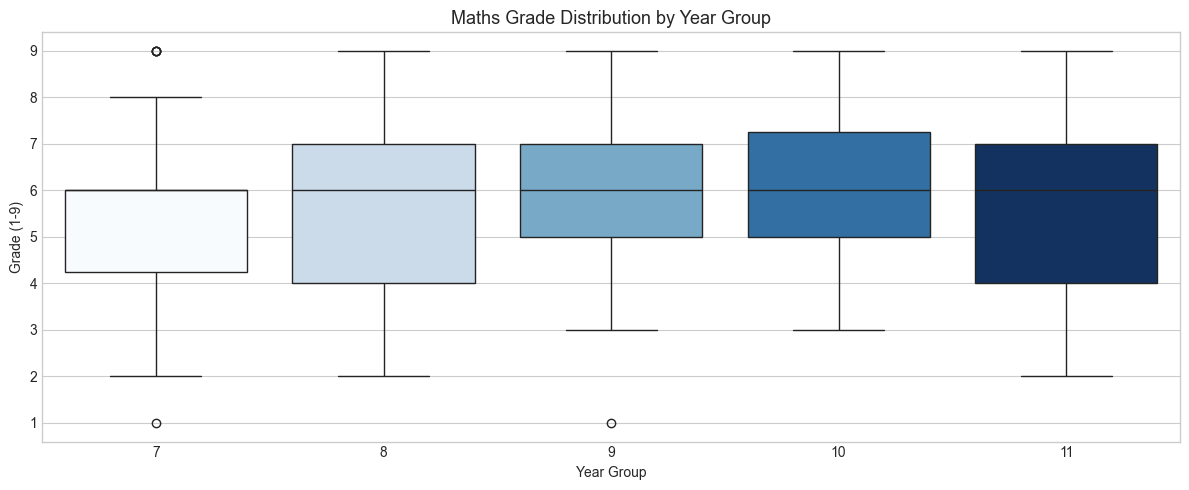

In [7]:
# Box plots: grade spread by year group — useful for spotting which cohort needs attention
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='year_group', y='maths_grade_y2', hue='year_group', palette='Blues', legend = False)
plt.title('Maths Grade Distribution by Year Group', fontsize=13)
plt.xlabel('Year Group')
plt.ylabel('Grade (1-9)')
plt.tight_layout()
plt.show()

**Reflections**


There seems to be no median line for year 7, and that for 8 is way up. This is not a plotting issue - it is a data issue.
- either the median for year 7 equals exactly Q1 or Q3 — seaborn draws the line but it sits flush with the box edge and disappears behind it.
- It typically means year 7 has very few data points or a heavily skewed distribution.

We can force the median line to a contrasting colour and thicker width so it's always visible regardless of where it falls:

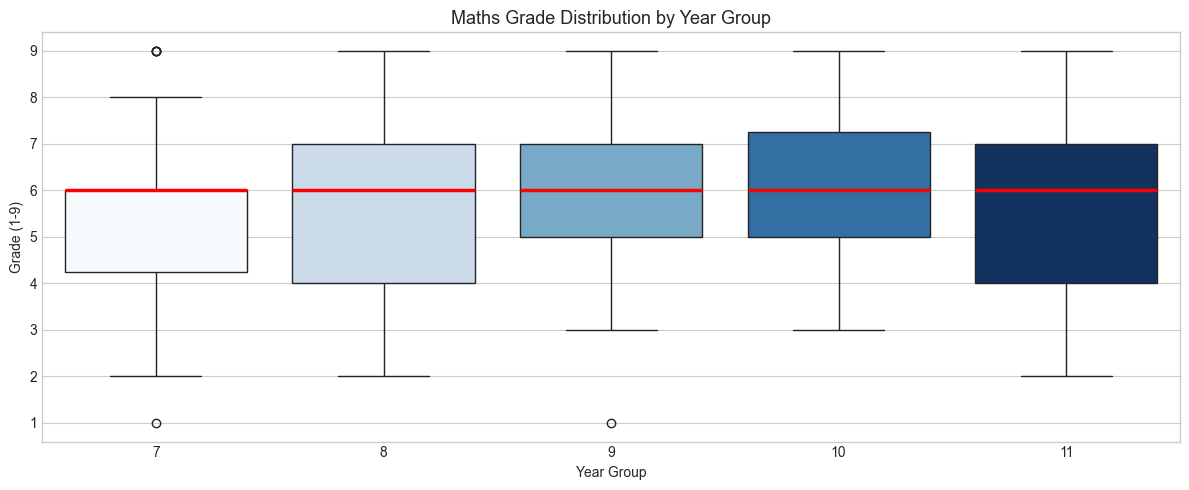

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='year_group', y='maths_grade_y2',
            hue='year_group', palette='Blues', legend=False,
            medianprops=dict(color='red', linewidth=2.5))
plt.title('Maths Grade Distribution by Year Group', fontsize=13)
plt.xlabel('Year Group')
plt.ylabel('Grade (1-9)')
plt.tight_layout()
plt.show()

## 5. Gender and house breakdown - pie charts

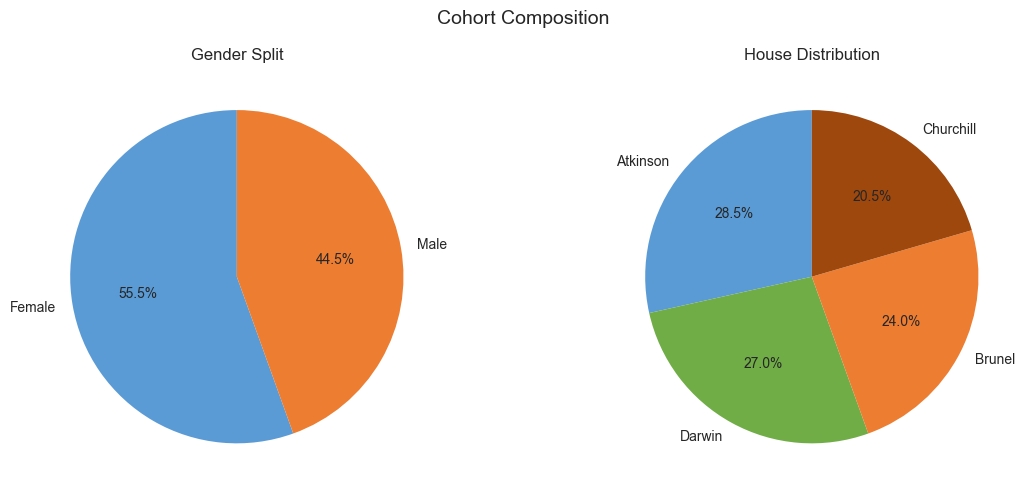

In [9]:
# Pie chart: gender split of the school cohort
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender pie
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[0].set_title('Gender Split', fontsize=12)

# House pie
house_counts = df['house'].value_counts()
axes[1].pie(house_counts, labels=house_counts.index, autopct='%1.1f%%',colors=['#5B9BD5','#70AD47','#ED7D31','#9E480E'], startangle=90)
axes[1].set_title('House Distribution', fontsize=12)

plt.suptitle('Cohort Composition', fontsize=14)
plt.tight_layout()
plt.show()


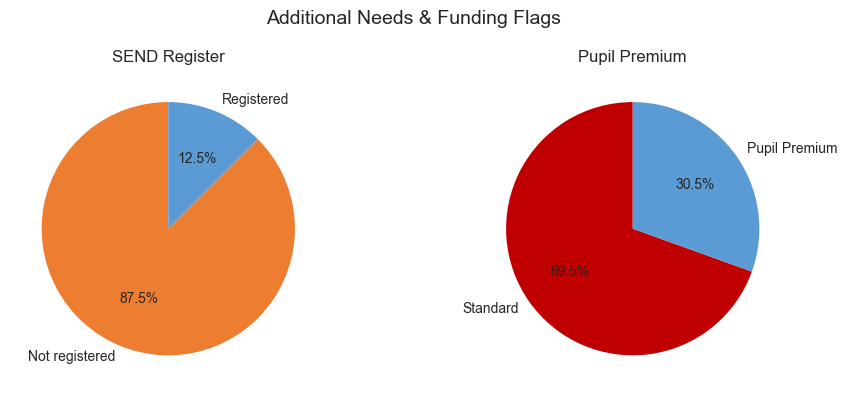

In [10]:
# Pie chart: proportion on SEND register and Pupil Premium

# Create 1 row of 2 side-by-side pie chart subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Iterate over both subplots together with their column name, title, and colours
for ax, col, title, colors in zip(
    axes,
    ['send_register', 'pupil_premium'],        # dataset column names
    ['SEND Register', 'Pupil Premium'],         # subplot titles
    [['#ED7D31','#5B9BD5'], ['#C00000','#5B9BD5']]  # colours per slice
):
    # Count how many pupils fall into each category (0 or 1) and sort for consistency
    counts = df[col].value_counts().sort_index()

    # Assign human-readable slice labels depending on which column is being plotted
    labels = ['Not registered', 'Registered'] if col == 'send_register' else ['Standard', 'Pupil Premium']

    # Draw the pie chart: show percentage on each slice, rotate so first slice starts at top
    ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)

    ax.set_title(title, fontsize=12)  # set individual subplot title

# Add a shared title across both subplots
plt.suptitle('Additional Needs & Funding Flags', fontsize=14)
plt.tight_layout()  # prevent overlapping elements
plt.show()

## 6. Attendance analysis
Persistent Absence is defined as below 90% in England. This section identifies pupils in that band.

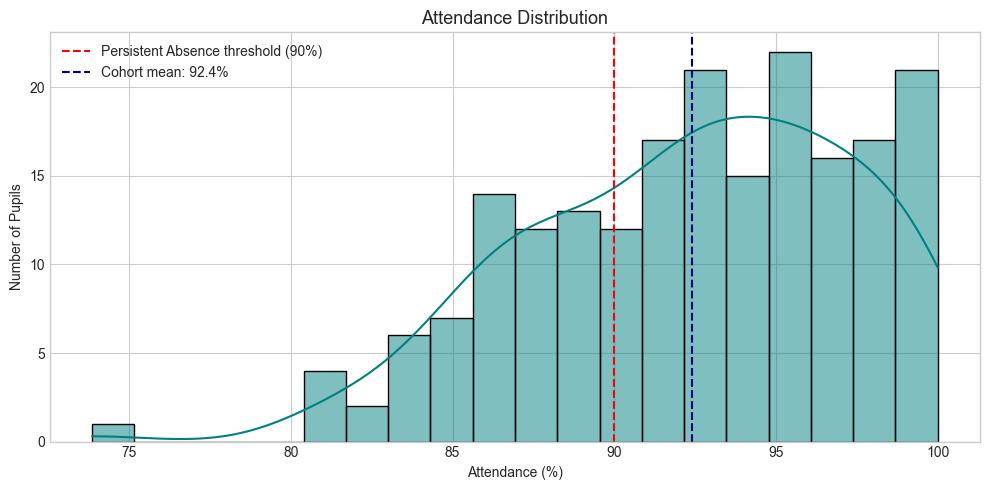

Persistently absent pupils (<90%): 62 (31.0% of cohort)


In [11]:
# Distribution of attendance across the cohort
plt.figure(figsize=(10, 5))
sns.histplot(df['attendance_pct'], bins=20, kde=True, color='teal')
plt.axvline(90, color='red', linestyle='--', label='Persistent Absence threshold (90%)')
plt.axvline(df['attendance_pct'].mean(), color='navy', linestyle='--',
            label=f"Cohort mean: {df['attendance_pct'].mean():.1f}%")
plt.title('Attendance Distribution', fontsize=13)
plt.xlabel('Attendance (%)')
plt.ylabel('Number of Pupils')
plt.legend()
plt.tight_layout()
plt.show()

# Count persistently absent pupils
pa_count = (df['attendance_pct'] < 90).sum()
print(f"Persistently absent pupils (<90%): {pa_count} ({pa_count/len(df)*100:.1f}% of cohort)")


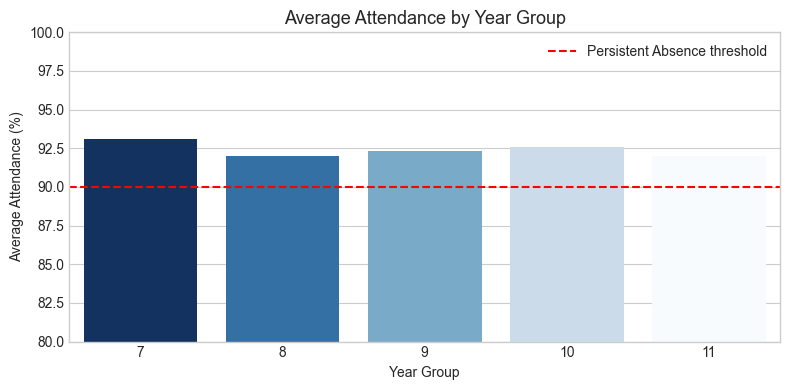

In [12]:
# Average attendance by year group — bar chart
avg_att = df.groupby('year_group')['attendance_pct'].mean().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=avg_att, x='year_group', y='attendance_pct',
            hue='year_group', palette='Blues_r', legend=False)
plt.axhline(90, color='red', linestyle='--', label='Persistent Absence threshold')
plt.title('Average Attendance by Year Group', fontsize=13)
plt.xlabel('Year Group')
plt.ylabel('Average Attendance (%)')
plt.ylim(80, 100)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Grade progression: Y1 to Y2 — line charts
Tracking movement between **report cycles** reveals which subjects are improving and which are declining across year groups.

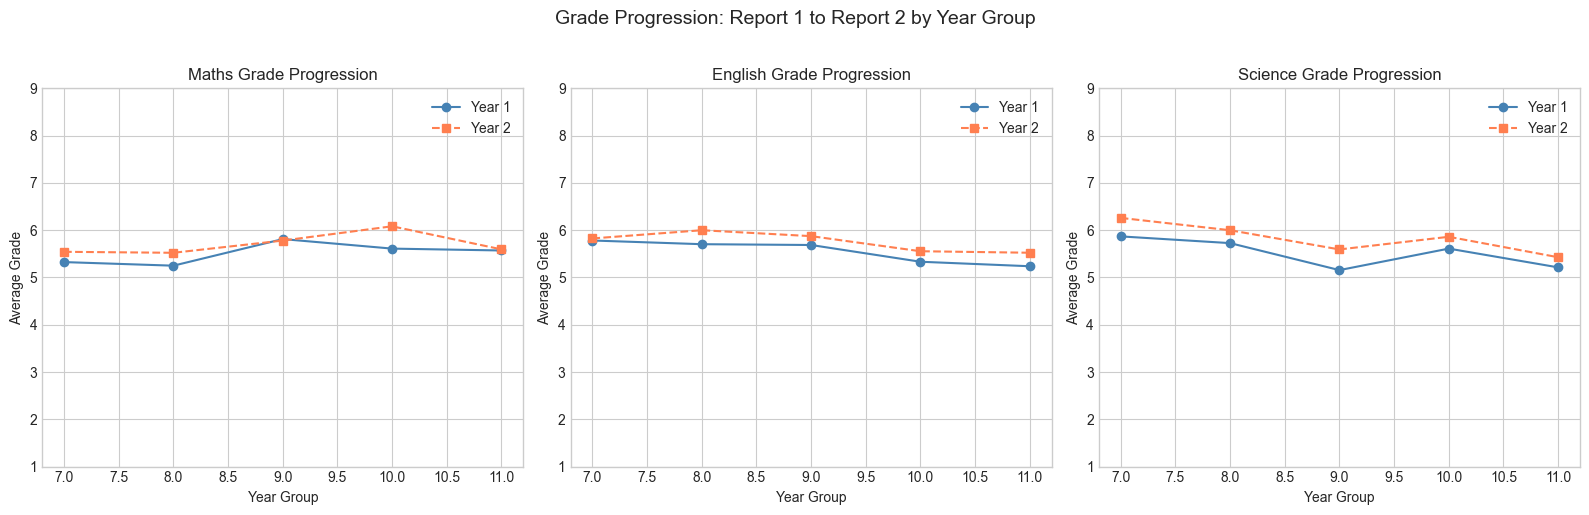

In [13]:
# Average grade Y1 vs Y2 for each subject, by year group
subjects_pairs = [
    ('maths_grade_y1',   'maths_grade_y2',   'Maths'),
    ('english_grade_y1', 'english_grade_y2', 'English'),
    ('science_grade_y1', 'science_grade_y2', 'Science'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (y1_col, y2_col, label) in zip(axes, subjects_pairs):
    means = df.groupby('year_group')[[y1_col, y2_col]].mean()
    ax.plot(means.index, means[y1_col], marker='o', label='Year 1', color='steelblue')
    ax.plot(means.index, means[y2_col], marker='s', label='Year 2', color='coral', linestyle='--')
    ax.set_title(f'{label} Grade Progression', fontsize=12)
    ax.set_xlabel('Year Group')
    ax.set_ylabel('Average Grade')
    ax.set_ylim(1, 9)
    ax.legend()

plt.suptitle('Grade Progression: Report 1 to Report 2 by Year Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


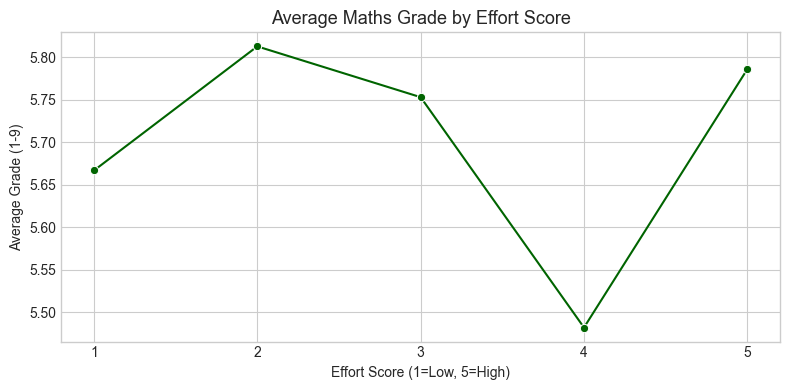

In [14]:
# Line chart: effort vs grade — are higher effort pupils achieving higher grades?
effort_grade = df.groupby('effort_maths').agg(
    avg_grade=('maths_grade_y2', 'mean'),
    count=('pupil_id', 'count')
).reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=effort_grade, x='effort_maths', y='avg_grade', marker='o', color='darkgreen')
plt.title('Average Maths Grade by Effort Score', fontsize=13)
plt.xlabel('Effort Score (1=Low, 5=High)')
plt.ylabel('Average Grade (1-9)')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()


## 8. Descriptive statistics by gender and year group

In [15]:
# Mean grades by gender — useful for monitoring gender attainment gaps
gender_stats = df.groupby('gender').agg(
    avg_maths  = ('maths_grade_y2',   'mean'),
    avg_english= ('english_grade_y2', 'mean'),
    avg_science= ('science_grade_y2', 'mean'),
    avg_attend = ('attendance_pct',   'mean'),
    avg_effort = ('effort_maths',     'mean'),
).round(2)
print("Average performance by gender:")
gender_stats


Average performance by gender:


,avg_maths,avg_english,avg_science,avg_attend,avg_effort
gender,,,,,
Female,5.82,5.82,5.59,92.22,3.23
Male,5.52,5.69,6.17,92.63,3.09


In [16]:
# Group by year group and compute summary statistics for each cohort
yg_stats = df.groupby('year_group').agg(
    pupils       = ('pupil_id',       'count'),  # total number of pupils in each year group
    avg_maths    = ('maths_grade_y2', 'mean'),   # mean maths grade at Report 2
    avg_attend   = ('attendance_pct', 'mean'),   # mean attendance percentage
    avg_rewards  = ('rewards',        'mean'),   # mean reward points per pupil
    avg_sanctions= ('sanctions',      'mean'),   # mean sanction count per pupil
    flagged_pct  = ('behaviour_flag', 'mean'),   # proportion flagged (0/1 mean = fraction)
).round(2)  # round all columns to 2 decimal places

# behaviour_flag mean gives a 0–1 fraction; multiply by 100 to express as a percentage
yg_stats['flagged_pct'] = (yg_stats['flagged_pct'] * 100).round(1)

print("Year group summary (flagged_pct = % on pastoral watchlist):")
yg_stats  # display the summary table


Year group summary (flagged_pct = % on pastoral watchlist):


,pupils,avg_maths,avg_attend,avg_rewards,avg_sanctions,flagged_pct
year_group,,,,,,
7,46,5.54,93.09,7.41,3.39,0.0
8,44,5.52,91.99,7.50,3.43,5.0
9,32,5.78,92.35,6.66,2.44,0.0
10,36,6.08,92.55,7.25,3.22,0.0
11,42,5.60,91.98,7.76,2.95,0.0


## 9. Correlation analysis
Do rewards and effort scores predict academic outcomes? Does attendance correlate with grades?

In [17]:
# Select numeric columns for correlation matrix
num_cols = ['attendance_pct', 'maths_grade_y2', 'english_grade_y2', 'science_grade_y2',
    'effort_maths', 'effort_english', 'effort_science',
    'predicted_grade', 'rewards', 'sanctions', 'cpoms_count']

corr = df[num_cols].corr()


corr # see it as a table

,attendance_pct,maths_grade_y2,english_grade_y2,science_grade_y2,effort_maths,effort_english,effort_science,predicted_grade,rewards,sanctions,cpoms_count
attendance_pct,1.000000,-0.022241,0.129277,0.068089,-0.055256,0.075206,0.032108,0.024528,0.081576,0.016761,-0.002723
maths_grade_y2,-0.022241,1.000000,0.128893,-0.012076,-0.035941,-0.035462,-0.017991,0.550903,0.003015,0.075662,0.143780
english_grade_y2,0.129277,0.128893,1.000000,0.072053,-0.065010,0.011520,-0.034236,0.566493,-0.129909,-0.172814,0.060127
science_grade_y2,0.068089,-0.012076,0.072053,1.000000,0.056381,-0.021931,-0.081813,0.470636,0.056423,0.114182,0.105401
effort_maths,-0.055256,-0.035941,-0.065010,0.056381,1.000000,0.000411,-0.022558,0.004211,-0.114437,0.046730,0.078039
effort_english,0.075206,-0.035462,0.011520,-0.021931,0.000411,1.000000,0.025651,-0.049046,0.069568,0.108064,0.085476
effort_science,0.032108,-0.017991,-0.034236,-0.081813,-0.022558,0.025651,1.000000,-0.096063,0.055068,0.097603,-0.101644
predicted_grade,0.024528,0.550903,0.566493,0.470636,0.004211,-0.049046,-0.096063,1.000000,0.003398,-0.042829,0.177016
rewards,0.081576,0.003015,-0.129909,0.056423,-0.114437,0.069568,0.055068,0.003398,1.000000,0.214646,-0.002958
sanctions,0.016761,0.075662,-0.172814,0.114182,0.046730,0.108064,0.097603,-0.042829,0.214646,1.000000,0.020155


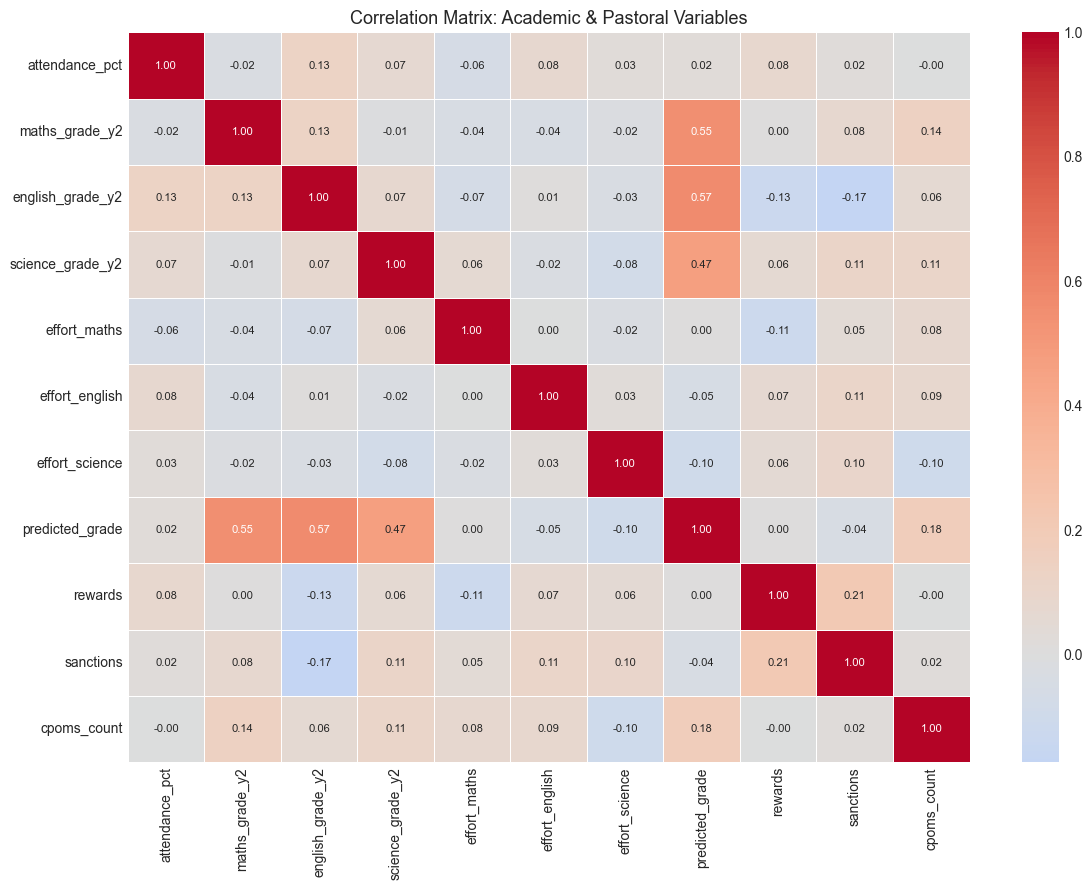

In [73]:
# Plot heatmap — darker blue = stronger positive correlation
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix: Academic & Pastoral Variables', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Pastoral data analysis - rewards, sanctions, CPOMS
Pastoral patterns can flag pupils who may be running into difficulties before grades drop.

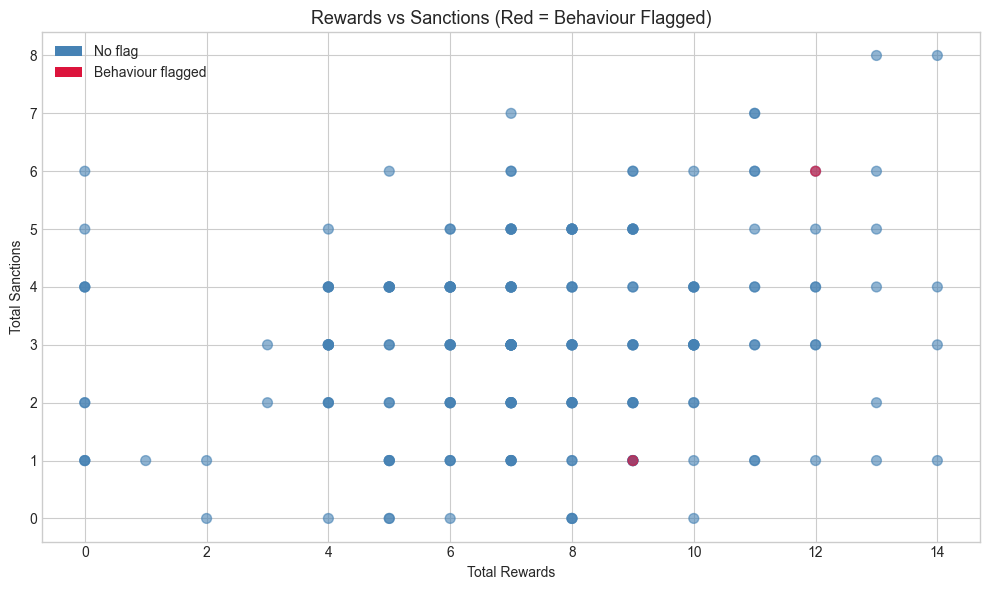

In [79]:
# Rewards vs sanctions scatter - flag the outliers
plt.figure(figsize=(10, 6))

# Map behaviour_flag (0 or 1) to a colour per pupil — blue = no flag, red = flagged
colours = df['behaviour_flag'].map({0: 'steelblue', 1: 'crimson'})

# Plot each pupil as a dot: x = total rewards, y = total sanctions, coloured by flag status
plt.scatter(df['rewards'], df['sanctions'], c=colours, alpha=0.6, s=50)
# alpha=0.6 adds transparency to reveal overlapping points; s=50 sets dot size

plt.xlabel('Total Rewards')
plt.ylabel('Total Sanctions')
plt.title('Rewards vs Sanctions (Red = Behaviour Flagged)', fontsize=13)

# Patch creates a solid-colour rectangle for the legend (scatter points can't auto-legend by colour)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='No flag'),
                   Patch(facecolor='crimson',   label='Behaviour flagged')]
plt.legend(handles=legend_elements)  # manually attach the colour-coded legend

plt.tight_layout()
plt.show()

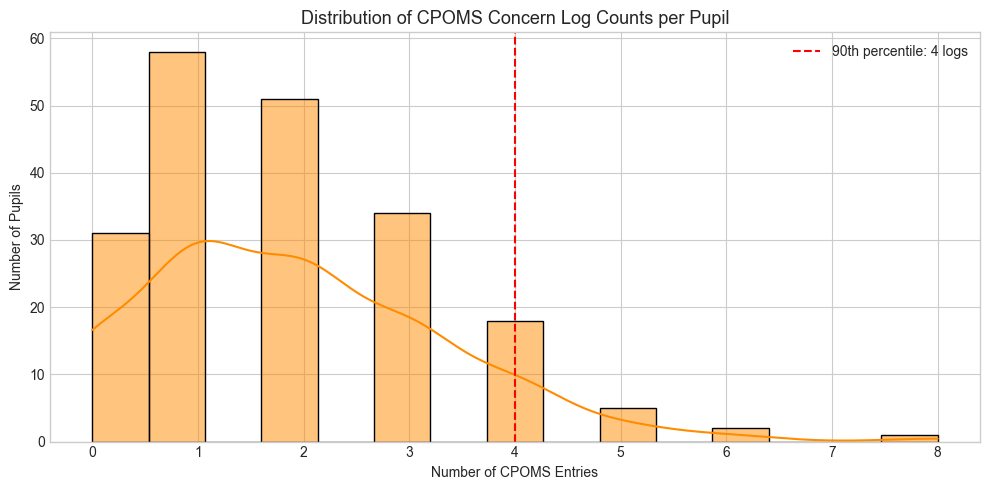

Pupils with 4+ CPOMS entries (top 10%): 26


In [77]:
# CPOMS log count distribution — how many concerns per pupil?
plt.figure(figsize=(10, 5))
sns.histplot(df['cpoms_count'], bins=15, kde=True, color='darkorange')
plt.axvline(df['cpoms_count'].quantile(0.9), color='red', linestyle='--',
            label=f"90th percentile: {df['cpoms_count'].quantile(0.9):.0f} logs")
plt.title('Distribution of CPOMS Concern Log Counts per Pupil', fontsize=13)
plt.xlabel('Number of CPOMS Entries')
plt.ylabel('Number of Pupils')
plt.legend()
plt.tight_layout()
plt.show()

# Identify high-concern pupils (above 90th percentile)
threshold = df['cpoms_count'].quantile(0.9)
high_cpoms = df[df['cpoms_count'] >= threshold]
print(f"Pupils with {threshold:.0f}+ CPOMS entries (top 10%): {len(high_cpoms)}")


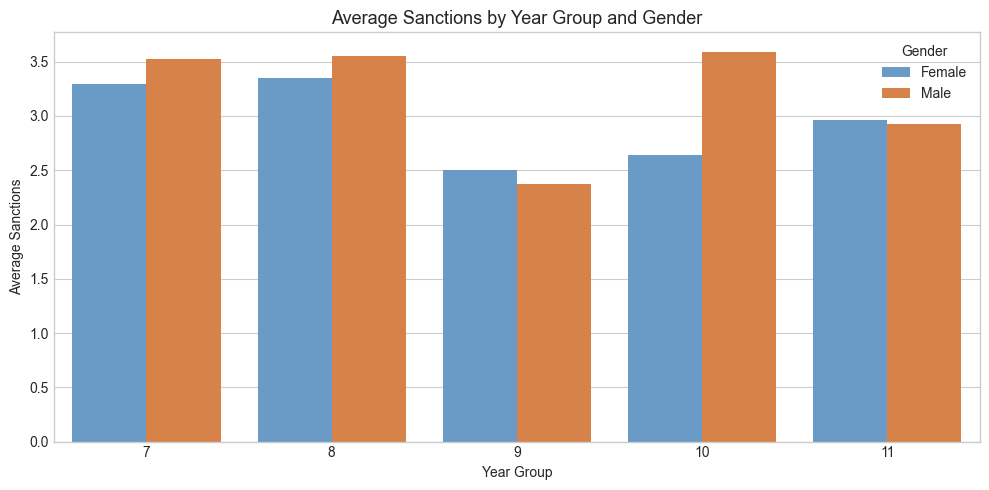

In [81]:
# Average sanctions by year group and gender — bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='year_group', y='sanctions', hue='gender', palette=['#5B9BD5','#ED7D31'], errorbar=None)
plt.title('Average Sanctions by Year Group and Gender', fontsize=13)
plt.xlabel('Year Group')
plt.ylabel('Average Sanctions')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


## 11. Feature engineering - derived metrics
Creating composite flags helps prioritise which pupils need pastoral or academic intervention.

In [82]:
# Academic progress: difference between Y1 and Y2 grades
df['maths_progress']   = df['maths_grade_y2']   - df['maths_grade_y1']
df['english_progress'] = df['english_grade_y2'] - df['english_grade_y1']
df['science_progress'] = df['science_grade_y2'] - df['science_grade_y1']

# Average effort across three subjects
df['avg_effort'] = df[['effort_maths','effort_english','effort_science']].mean(axis=1).round(2)

# Average grade across three subjects (Y2)
df['avg_grade_y2'] = df[['maths_grade_y2','english_grade_y2','science_grade_y2']].mean(axis=1).round(2)

# Pastoral risk score: combines sanctions, CPOMS, and low attendance
df['pastoral_risk_score'] = (
    (df['sanctions'] > df['sanctions'].quantile(0.75)).astype(int) +
    (df['cpoms_count'] > df['cpoms_count'].quantile(0.75)).astype(int) +
    (df['attendance_pct'] < 90).astype(int)
)  # score 0-3; 2+ = elevated concern

print("New columns added:", ['maths_progress','english_progress','science_progress',
                               'avg_effort','avg_grade_y2','pastoral_risk_score'])
df[['pupil_id','avg_grade_y2','avg_effort','maths_progress','pastoral_risk_score']].head(8)


New columns added: ['maths_progress', 'english_progress', 'science_progress', 'avg_effort', 'avg_grade_y2', 'pastoral_risk_score']


,pupil_id,avg_grade_y2,avg_effort,maths_progress,pastoral_risk_score
0,P0001,4.67,3.00,-1.0,1
1,P0002,6.00,2.67,0.0,0
2,P0003,8.00,3.33,0.0,0
3,P0004,7.33,2.67,1.0,0
4,P0005,6.33,2.67,-2.0,1
5,P0006,6.00,3.67,0.0,1
6,P0007,6.00,3.33,0.0,1
7,P0008,5.00,3.67,0.0,2


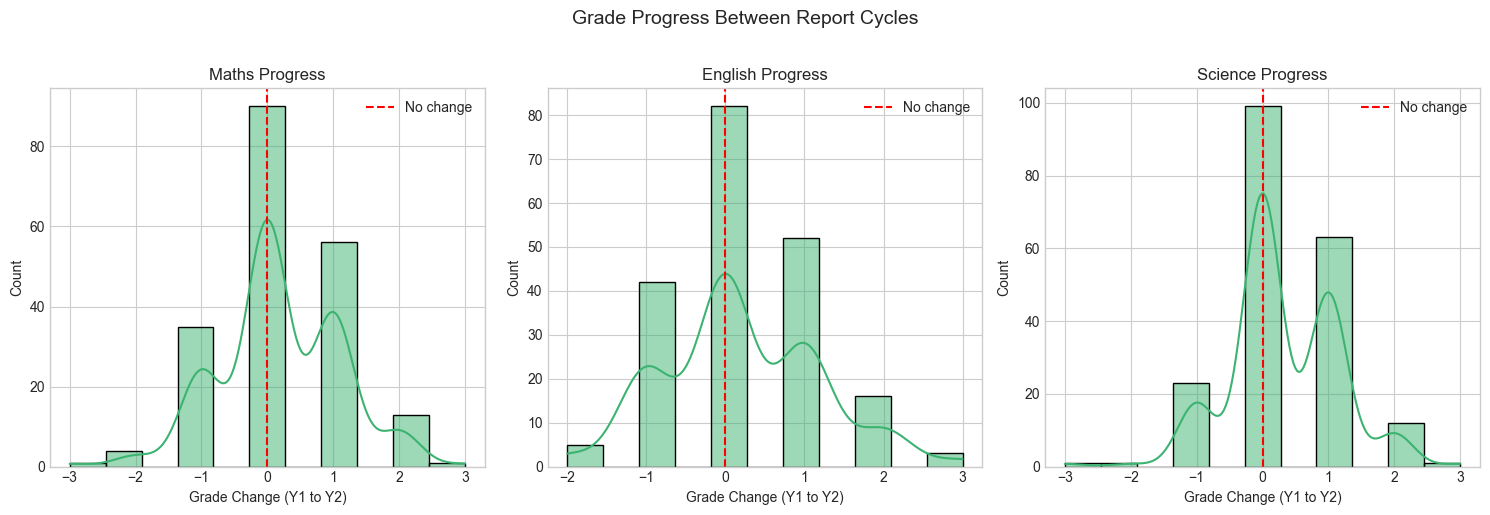

In [83]:
# Distribution of academic progress scores (positive = improvement)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(axes,
    ['maths_progress','english_progress','science_progress'],
    ['Maths Progress','English Progress','Science Progress']):
    sns.histplot(df[col], bins=11, kde=True, ax=ax, color='mediumseagreen')
    ax.axvline(0, color='red', linestyle='--', label='No change')
    ax.set_title(title)
    ax.set_xlabel('Grade Change (Y1 to Y2)')
    ax.legend()
plt.suptitle('Grade Progress Between Report Cycles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


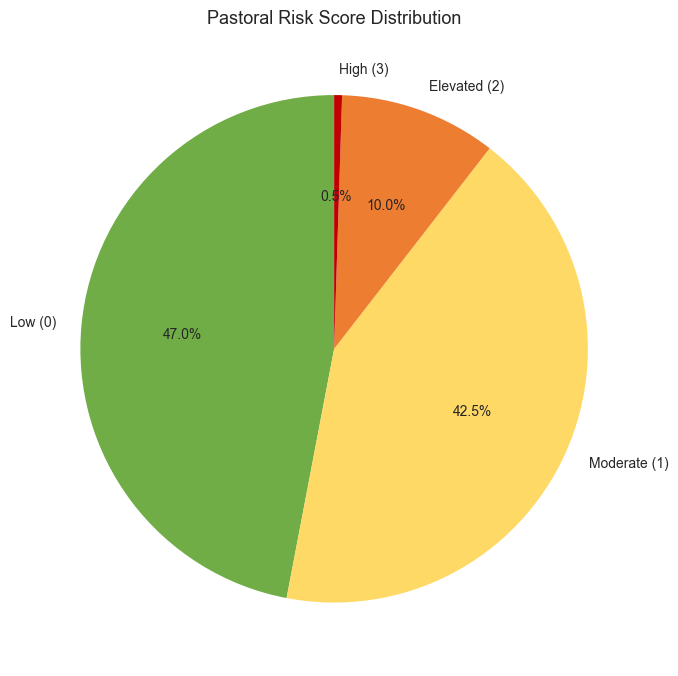

In [84]:
# Pastoral risk score breakdown — pie chart
risk_counts = df['pastoral_risk_score'].value_counts().sort_index()
labels = {0:'Low (0)', 1:'Moderate (1)', 2:'Elevated (2)', 3:'High (3)'}
pie_labels = [labels.get(i, str(i)) for i in risk_counts.index]
colours = ['#70AD47','#FFD966','#ED7D31','#C00000']

plt.figure(figsize=(7, 7))
plt.pie(risk_counts, labels=pie_labels, autopct='%1.1f%%',
        colors=colours[:len(risk_counts)], startangle=90)
plt.title('Pastoral Risk Score Distribution', fontsize=13)
plt.tight_layout()
plt.show()


## 12. Pivot tables - cross-tabulated insight

In [85]:
# Mean maths grade by year group and gender
pivot_grades = pd.pivot_table(
    df, values='maths_grade_y2',
    index='year_group', columns='gender', aggfunc='mean'
).round(2)
print("Mean Maths Grade by Year Group and Gender:")
pivot_grades


Mean Maths Grade by Year Group and Gender:


gender,Female,Male
year_group,,
7,5.89,5.05
8,5.31,5.83
9,6.00,5.56
10,6.79,5.64
11,5.64,5.50


In [86]:
# Behaviour flag rate by house and year group
pivot_behaviour = pd.pivot_table(
    df, values='behaviour_flag',
    index='house', columns='year_group', aggfunc='mean'
).round(3) * 100  # convert to percentage

print("% of pupils behaviour-flagged by House and Year Group:")
pivot_behaviour.style.format("{:.1f}%")  # format as percentage


% of pupils behaviour-flagged by House and Year Group:


year_group,7,8,9,10,11
house,,,,,
Atkinson,0.0%,5.9%,0.0%,0.0%,0.0%
Brunel,0.0%,0.0%,0.0%,0.0%,0.0%
Churchill,0.0%,0.0%,0.0%,0.0%,0.0%
Darwin,0.0%,12.5%,0.0%,0.0%,0.0%


In [87]:
# Average CPOMS count by SEND status and Pupil Premium — identifying intersecting needs
pivot_cpoms = pd.pivot_table(
    df, values='cpoms_count',
    index='send_register', columns='pupil_premium', aggfunc='mean'
).round(2)
pivot_cpoms.index   = ['Not on SEND', 'On SEND Register']
pivot_cpoms.columns = ['Standard', 'Pupil Premium']
print("Average CPOMS Entries by SEND and Pupil Premium status:")
pivot_cpoms


Average CPOMS Entries by SEND and Pupil Premium status:


,Standard,Pupil Premium
Not on SEND,1.93,1.90
On SEND Register,1.38,2.33


## 13. Predictive indicators - linking pastoral & academic data
This section explores which variables best predict whether a pupil will meet their predicted grade.
This is the foundation for building an ML model later (e.g. logistic regression or a decision tree).


In [89]:
# Create a binary outcome: did the pupil meet or exceed their predicted grade?
df['met_prediction'] = (df['avg_grade_y2'] >= df['predicted_grade']).astype(int)
met_rate = df['met_prediction'].mean() * 100
print(f"Pupils meeting or exceeding predicted grade: {met_rate:.1f}%")

# Compare key variables between those who met vs did not meet prediction
comparison = df.groupby('met_prediction').agg(
    avg_attendance  = ('attendance_pct',     'mean'),
    avg_effort      = ('avg_effort',         'mean'),
    avg_rewards     = ('rewards',            'mean'),
    avg_sanctions   = ('sanctions',          'mean'),
    avg_cpoms       = ('cpoms_count',        'mean'),
    avg_risk_score  = ('pastoral_risk_score','mean'),
).round(2)
comparison.index = ['Did not meet prediction', 'Met or exceeded prediction']
print("\nKey indicators by outcome:")
comparison


Pupils meeting or exceeding predicted grade: 60.5%

Key indicators by outcome:


,avg_attendance,avg_effort,avg_rewards,avg_sanctions,avg_cpoms,avg_risk_score
Did not meet prediction,91.67,3.02,7.59,2.99,2.09,0.65
Met or exceeded prediction,92.87,3.13,7.20,3.21,1.77,0.64


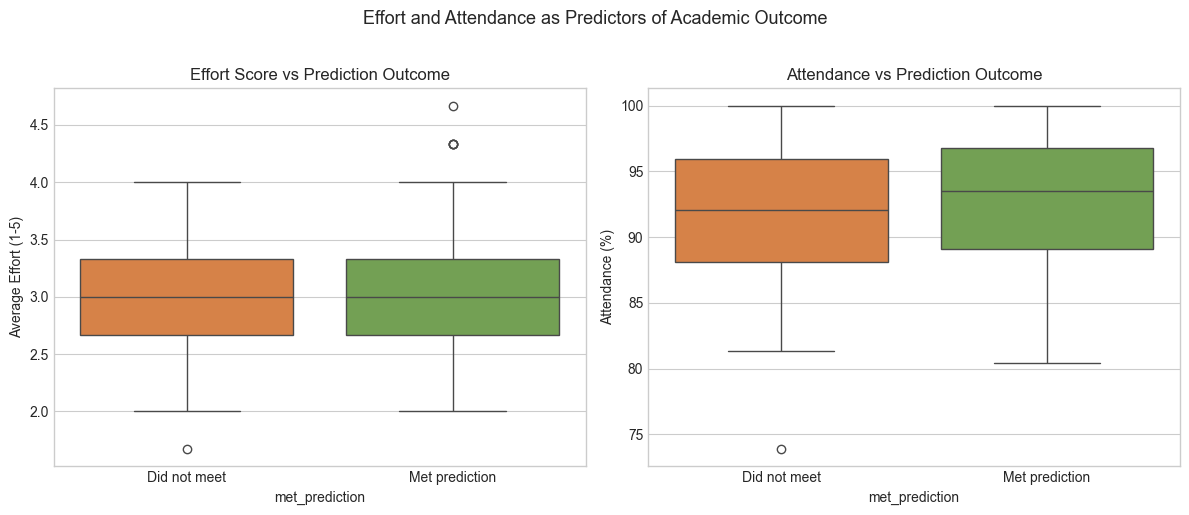

In [91]:
# Visual summary: effort and attendance by whether prediction was met
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Effort distribution
sns.boxplot(data=df, x='met_prediction', y='avg_effort',
            hue='met_prediction', palette=['#ED7D31','#70AD47'],
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])  # explicitly fix tick positions before labelling
axes[0].set_xticklabels(['Did not meet', 'Met prediction'])
axes[0].set_title('Effort Score vs Prediction Outcome')
axes[0].set_ylabel('Average Effort (1-5)')

# Attendance distribution
sns.boxplot(data=df, x='met_prediction', y='attendance_pct',
            hue='met_prediction', palette=['#ED7D31','#70AD47'],
            legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])  # explicitly fix tick positions before labelling
axes[1].set_xticklabels(['Did not meet', 'Met prediction'])
axes[1].set_title('Attendance vs Prediction Outcome')
axes[1].set_ylabel('Attendance (%)')

plt.suptitle('Effort and Attendance as Predictors of Academic Outcome', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 14. Summary report - key findings for the pastoral and academic team

In [92]:
print("=" * 60)
print("       SCHOOL DATA ANALYSIS — SUMMARY REPORT")
print("=" * 60)

print(f"\nTotal pupils analysed:        {len(df)}")
print(f"Year groups:                  {sorted(df['year_group'].unique())}")

print("\n--- ACADEMIC ---")
print(f"Average Maths grade (Y2):     {df['maths_grade_y2'].mean():.2f}")
print(f"Average English grade (Y2):   {df['english_grade_y2'].mean():.2f}")
print(f"Average Science grade (Y2):   {df['science_grade_y2'].mean():.2f}")
print(f"Pupils meeting prediction:    {df['met_prediction'].mean()*100:.1f}%")

print("\n--- ATTENDANCE ---")
pa = (df['attendance_pct'] < 90).sum()
print(f"Persistently absent (<90%):   {pa} pupils ({pa/len(df)*100:.1f}%)")
print(f"Average attendance:           {df['attendance_pct'].mean():.1f}%")

print("\n--- PASTORAL ---")
high_risk = (df['pastoral_risk_score'] >= 2).sum()
print(f"Elevated/High pastoral risk:  {high_risk} pupils ({high_risk/len(df)*100:.1f}%)")
top_cpoms = df.nlargest(5, 'cpoms_count')[['pupil_id','year_group','cpoms_count','behaviour_flag']]
print("\nTop 5 pupils by CPOMS entries:")
print(top_cpoms.to_string(index=False))

print("\n--- SEND & PUPIL PREMIUM ---")
print(f"On SEND register:             {df['send_register'].sum()} pupils")
print(f"Pupil premium eligible:       {df['pupil_premium'].sum()} pupils")
print("=" * 60)


       SCHOOL DATA ANALYSIS — SUMMARY REPORT

Total pupils analysed:        200
Year groups:                  [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

--- ACADEMIC ---
Average Maths grade (Y2):     5.68
Average English grade (Y2):   5.76
Average Science grade (Y2):   5.85
Pupils meeting prediction:    60.5%

--- ATTENDANCE ---
Persistently absent (<90%):   62 pupils (31.0%)
Average attendance:           92.4%

--- PASTORAL ---
Elevated/High pastoral risk:  21 pupils (10.5%)

Top 5 pupils by CPOMS entries:
pupil_id  year_group  cpoms_count  behaviour_flag
   P0081          11          8.0               0
   P0008          11          6.0               0
   P0052          10          6.0               0
   P0069           7          5.0               0
   P0094           9          5.0               0

--- SEND & PUPIL PREMIUM ---
On SEND register:             25 pupils
Pupil premium eligible:       61 pupils
